In [1]:
!pip install -q transformers datasets accelerate scikit-learn

In [2]:
import json
import pandas as pd
import numpy as np
import torch
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seeds fixed")

Seeds fixed


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
course_df = pd.read_csv(
    "/content/drive/MyDrive/ABSA/course_balanced.csv"
)

teacher_df = pd.read_csv(
    "/content/drive/MyDrive/ABSA/teacher_balanced.csv"
)

university_df = pd.read_csv(
    "/content/drive/MyDrive/ABSA/university_balanced.csv"
)


In [5]:
course_df["row_id"] = [
    f"course_{i}" for i in range(len(course_df))
]

teacher_df["row_id"] = [
    f"teacher_{i}" for i in range(len(teacher_df))
]

university_df["row_id"] = [
    f"university_{i}" for i in range(len(university_df))
]

In [6]:
print(course_df[["row_id"]].head())

print(teacher_df[["row_id"]].head())

print(university_df[["row_id"]].head())

     row_id
0  course_0
1  course_1
2  course_2
3  course_3
4  course_4
      row_id
0  teacher_0
1  teacher_1
2  teacher_2
3  teacher_3
4  teacher_4
         row_id
0  university_0
1  university_1
2  university_2
3  university_3
4  university_4


In [7]:
def format_input(row):

    return (
        "[DOMAIN] " + row["domain"] +
        " [ASPECT] " + row["aspect"] +
        " [TEXT] " + row["review"]
    )


course_df["input_text"] = course_df.apply(
    format_input,
    axis=1
)

teacher_df["input_text"] = teacher_df.apply(
    format_input,
    axis=1
)

university_df["input_text"] = university_df.apply(
    format_input,
    axis=1
)


print(course_df["input_text"].iloc[0])

print(teacher_df["input_text"].iloc[0])

print(university_df["input_text"].iloc[0])

[DOMAIN] course [ASPECT] course [TEXT] This course was amazing. For the first time, there's no worrying about your lab partner: it's just you and the chemicals. When I took this course, it was just 4 long experiments and you organize your time accordingly throughout the semester: for students taking it in Fall 2016, you now have 7+ experiments, so I'm not sure how much the formatting's changed. It's a lot of work, but it's incredibly rewarding. I loved it.
[DOMAIN] teacher [ASPECT] Scott Hopkins [TEXT] First of all, shoutout to Scott Hopkins for the best Module Videos- he made me fall in love with Chemistry. This course is pretty easy if you've done Chemistry in high school before. The course content is structured really well and the video are amazing in helping you learn. Plenty of examples, and the assessment structure for this course is pretty good as well. Overall, really recommend this course for any non-science major looking to take up a science elective!
[DOMAIN] university [ASP

In [8]:
label_mapping = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

course_df["label"] = course_df["sentiment"].map(
    label_mapping
)

teacher_df["label"] = teacher_df["sentiment"].map(
    label_mapping
)

university_df["label"] = university_df["sentiment"].map(
    label_mapping
)

print(course_df[["sentiment", "label"]].head())

print(teacher_df[["sentiment", "label"]].head())

print(university_df[["sentiment", "label"]].head())

  sentiment  label
0  positive      2
1  positive      2
2  negative      0
3  positive      2
4  positive      2
  sentiment  label
0  positive      2
1  negative      0
2  positive      2
3  negative      0
4  positive      2
  sentiment  label
0  negative      0
1  positive      2
2  positive      2
3  positive      2
4  positive      2


In [9]:
from sklearn.model_selection import train_test_split

# =====================================================
# COURSE SPLIT
# =====================================================

course_train, course_test = train_test_split(
    course_df,
    test_size=0.2,
    stratify=course_df["label"],
    random_state=42
)

# =====================================================
# TEACHER SPLIT
# =====================================================

teacher_train, teacher_test = train_test_split(
    teacher_df,
    test_size=0.2,
    stratify=teacher_df["label"],
    random_state=42
)

# =====================================================
# UNIVERSITY SPLIT
# =====================================================

university_train, university_test = train_test_split(
    university_df,
    test_size=0.2,
    stratify=university_df["label"],
    random_state=42
)

print("Course test:", course_test.shape)
print("Teacher test:", teacher_test.shape)
print("University test:", university_test.shape)

Course test: (844, 7)
Teacher test: (844, 7)
University test: (844, 7)


In [10]:
test_df = pd.concat([
    course_test,
    teacher_test,
    university_test
]).reset_index(drop=True)

print(test_df.shape)

print(test_df["domain"].value_counts())

(2532, 7)
domain
course        844
teacher       844
university    844
Name: count, dtype: int64


In [11]:
train_df = pd.concat([
    course_train,
    teacher_train,
    university_train
]).reset_index(drop=True)

print(train_df.shape)

print(train_df["domain"].value_counts())

(10122, 7)
domain
course        3374
teacher       3374
university    3374
Name: count, dtype: int64


In [12]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (9109, 7)
Validation: (1013, 7)


In [13]:
print("TRAIN LABELS:\n")
print(train_df["label"].value_counts())


print("\nVALIDATION LABELS:\n")
print(val_df["label"].value_counts())


print("\nTEST LABELS:\n")
print(test_df["label"].value_counts())

TRAIN LABELS:

label
2    5589
0    2555
1     965
Name: count, dtype: int64

VALIDATION LABELS:

label
2    622
0    284
1    107
Name: count, dtype: int64

TEST LABELS:

label
2    1553
0     711
1     268
Name: count, dtype: int64


In [14]:
from datasets import Dataset

train_df = train_df.reset_index(drop=True)

val_df = val_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)


train_dataset = Dataset.from_pandas(
    train_df[["input_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["input_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["input_text", "label"]]
)


print(train_dataset)

print(val_dataset)

print(test_dataset)

Dataset({
    features: ['input_text', 'label'],
    num_rows: 9109
})
Dataset({
    features: ['input_text', 'label'],
    num_rows: 1013
})
Dataset({
    features: ['input_text', 'label'],
    num_rows: 2532
})


In [15]:
import os

os.makedirs(
    "/content/drive/MyDrive/ABSA/test_sets",
    exist_ok=True
)

print("test_sets folder ready")

test_sets folder ready


In [16]:
teacher_test.to_csv(
    "/content/drive/MyDrive/ABSA/test_sets/teacher_test.csv",
    index=False
)

course_test.to_csv(
    "/content/drive/MyDrive/ABSA/test_sets/course_test.csv",
    index=False
)

university_test.to_csv(
    "/content/drive/MyDrive/ABSA/test_sets/university_test.csv",
    index=False
)

print("Shared test sets saved")

Shared test sets saved


In [17]:
print("TRAIN LABELS:\n")
print(train_df["label"].value_counts())

print("\nVALIDATION LABELS:\n")
print(val_df["label"].value_counts())

print("\nTEACHER TEST LABELS:\n")
print(teacher_test["label"].value_counts())

print("\nCOURSE TEST LABELS:\n")
print(course_test["label"].value_counts())

print("\nUNIVERSITY TEST LABELS:\n")
print(university_test["label"].value_counts())

TRAIN LABELS:

label
2    5589
0    2555
1     965
Name: count, dtype: int64

VALIDATION LABELS:

label
2    622
0    284
1    107
Name: count, dtype: int64

TEACHER TEST LABELS:

label
2    469
0    288
1     87
Name: count, dtype: int64

COURSE TEST LABELS:

label
2    408
0    291
1    145
Name: count, dtype: int64

UNIVERSITY TEST LABELS:

label
2    676
0    132
1     36
Name: count, dtype: int64


In [18]:
model_name = "answerdotai/ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [19]:
def tokenize_function(examples):

    return tokenizer(
        examples["input_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/9109 [00:00<?, ? examples/s]

Map:   0%|          | 0/1013 [00:00<?, ? examples/s]

Map:   0%|          | 0/2532 [00:00<?, ? examples/s]

In [20]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [21]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
from sklearn.utils.class_weight import compute_class_weight

labels = train_df["label"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print(class_weights)

tensor([1.1884, 3.1465, 0.5433])


In [23]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),

        "f1_macro": f1_score(
            labels,
            preds,
            average="macro"
        ),

        "f1_weighted": f1_score(
            labels,
            preds,
            average="weighted"
        )
    }

In [24]:
import torch.nn as nn

class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.get("labels")

        outputs = model(**inputs)

        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights.to(model.device)
        )

        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [25]:
training_args = TrainingArguments(
    output_dir="/content/modernbert_multidomain",

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=1,

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",

    fp16=True
)

In [26]:
trainer = WeightedTrainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [27]:
trainer.train()

W0512 12:55:50.458000 3189 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.558268,0.534436,0.760118,0.697190,0.796003
2,0.391062,0.508557,0.870681,0.786583,0.875011
3,0.244870,0.681599,0.893386,0.819283,0.893653
4,0.126203,1.277133,0.889437,0.805188,0.889462
5,0.034325,1.490572,0.888450,0.801826,0.888514


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2850, training_loss=0.30206786979708755, metrics={'train_runtime': 726.6371, 'train_samples_per_second': 62.679, 'train_steps_per_second': 3.922, 'total_flos': 3879980922712320.0, 'train_loss': 0.30206786979708755, 'epoch': 5.0})

In [28]:
test_results = trainer.evaluate(test_dataset)

print(test_results)

{'eval_loss': 0.5993229746818542, 'eval_accuracy': 0.8799368088467614, 'eval_f1_macro': 0.7965389189336922, 'eval_f1_weighted': 0.8804613455066197, 'eval_runtime': 9.6198, 'eval_samples_per_second': 263.207, 'eval_steps_per_second': 16.528, 'epoch': 5.0}


In [29]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [30]:
from sklearn.metrics import classification_report

target_names = [
    "negative",
    "neutral",
    "positive"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

    negative       0.88      0.89      0.88       711
     neutral       0.57      0.58      0.58       268
    positive       0.94      0.93      0.93      1553

    accuracy                           0.88      2532
   macro avg       0.79      0.80      0.80      2532
weighted avg       0.88      0.88      0.88      2532



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[ 631   48   32]
 [  48  156   64]
 [  42   70 1441]]


In [32]:
trainer.save_model(
    "/content/drive/MyDrive/ABSA/models/modernbert_multidomain"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/ABSA/models/modernbert_multidomain"
)

print("Model saved successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully


In [33]:
results_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred
})

results_df.to_csv(
    "/content/drive/MyDrive/ABSA/models/modernbert_predictions.csv",
    index=False
)

print("Predictions saved")

Predictions saved


In [34]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Accuracy",
        "Macro F1",
        "Weighted F1"
    ],

    "Score": [
        test_results["eval_loss"],
        test_results["eval_accuracy"],
        test_results["eval_f1_macro"],
        test_results["eval_f1_weighted"]
    ]
})

metrics_df.to_csv(
    "/content/drive/MyDrive/ABSA/models/modernbert_test_metrics.csv",
    index=False
)

print(metrics_df)

        Metric     Score
0    Test Loss  0.599323
1     Accuracy  0.879937
2     Macro F1  0.796539
3  Weighted F1  0.880461


In [35]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=[
        "negative",
        "neutral",
        "positive"
    ],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "/content/drive/MyDrive/ABSA/models/modernbert_classification_report.csv"
)

print(report_df)

              precision    recall  f1-score      support
negative       0.875173  0.887482  0.881285   711.000000
neutral        0.569343  0.582090  0.575646   268.000000
positive       0.937541  0.927882  0.932686  1553.000000
accuracy       0.879937  0.879937  0.879937     0.879937
macro avg      0.794019  0.799151  0.796539  2532.000000
weighted avg   0.881056  0.879937  0.880461  2532.000000


In [36]:
cm_df = pd.DataFrame(
    cm,

    index=[
        "Actual Negative",
        "Actual Neutral",
        "Actual Positive"
    ],

    columns=[
        "Pred Negative",
        "Pred Neutral",
        "Pred Positive"
    ]
)

cm_df.to_csv(
    "/content/drive/MyDrive/ABSA/models/modernbert_confusion_matrix.csv"
)

print(cm_df)

                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            631            48             32
Actual Neutral              48           156             64
Actual Positive             42            70           1441


In [37]:
history = trainer.state.log_history

history_df = pd.DataFrame(history)

history_df.to_csv(
    "/content/drive/MyDrive/ABSA/models/modernbert_training_history.csv",
    index=False
)

print(history_df.head())

       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.990888  11.756330       0.000019  0.175439   100        NaN   
1  0.784961   4.881938       0.000019  0.350877   200        NaN   
2  0.645620  13.891921       0.000018  0.526316   300        NaN   
3  0.636353  28.014051       0.000017  0.701754   400        NaN   
4  0.558268  19.205353       0.000016  0.877193   500        NaN   

   eval_accuracy  eval_f1_macro  eval_f1_weighted  eval_runtime  \
0            NaN            NaN               NaN           NaN   
1            NaN            NaN               NaN           NaN   
2            NaN            NaN               NaN           NaN   
3            NaN            NaN               NaN           NaN   
4            NaN            NaN               NaN           NaN   

   eval_samples_per_second  eval_steps_per_second  train_runtime  \
0                      NaN                    NaN            NaN   
1                      NaN                    NaN   

In [38]:
eval_history = history_df[
    history_df["eval_loss"].notna()
]

print(eval_history)

    loss  grad_norm  learning_rate  epoch  step  eval_loss  eval_accuracy  \
5    NaN        NaN            NaN    1.0   570   0.534436       0.760118   
12   NaN        NaN            NaN    2.0  1140   0.508557       0.870681   
19   NaN        NaN            NaN    3.0  1710   0.681599       0.893386   
25   NaN        NaN            NaN    4.0  2280   1.277133       0.889437   
32   NaN        NaN            NaN    5.0  2850   1.490572       0.888450   
34   NaN        NaN            NaN    5.0  2850   0.599323       0.879937   

    eval_f1_macro  eval_f1_weighted  eval_runtime  eval_samples_per_second  \
5        0.697190          0.796003        7.2078                  140.542   
12       0.786583          0.875011        3.9257                  258.045   
19       0.819283          0.893653        3.9502                  256.444   
25       0.805188          0.889462        3.9494                  256.497   
32       0.801826          0.888514        3.9052                  259

In [39]:
train_results = trainer.evaluate(train_dataset)

print(train_results)

{'eval_loss': 0.09968534857034683, 'eval_accuracy': 0.9767263146338786, 'eval_f1_macro': 0.9621314047547468, 'eval_f1_weighted': 0.9767540961142317, 'eval_runtime': 39.2162, 'eval_samples_per_second': 232.276, 'eval_steps_per_second': 14.535, 'epoch': 5.0}


In [40]:
train_predictions = trainer.predict(train_dataset)

train_y_pred = np.argmax(
    train_predictions.predictions,
    axis=1
)

train_y_true = train_predictions.label_ids

print(
    classification_report(
        train_y_true,
        train_y_pred,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.97      0.99      0.98      2555
     neutral       0.92      0.92      0.92       965
    positive       0.99      0.98      0.99      5589

    accuracy                           0.98      9109
   macro avg       0.96      0.96      0.96      9109
weighted avg       0.98      0.98      0.98      9109



In [41]:
model_4epoch = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [42]:
training_args_4epoch = TrainingArguments(
    output_dir="/content/modernbert_multidomain_4epoch",

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=1,

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=4,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",

    fp16=True
)

In [43]:
trainer_4epoch = WeightedTrainer(
    model=model_4epoch,

    args=training_args_4epoch,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [44]:
trainer_4epoch.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.570046,0.501790,0.816387,0.744211,0.837892
2,0.358932,0.529465,0.877591,0.795426,0.880067
3,0.236347,0.712209,0.890424,0.815468,0.890870
4,0.099376,1.130883,0.886476,0.805956,0.885802


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2280, training_loss=0.3538498274066992, metrics={'train_runtime': 565.1493, 'train_samples_per_second': 64.471, 'train_steps_per_second': 4.034, 'total_flos': 3103984738169856.0, 'train_loss': 0.3538498274066992, 'epoch': 4.0})

In [45]:
test_results_4epoch = trainer_4epoch.evaluate(test_dataset)

print(test_results_4epoch)

{'eval_loss': 0.6271414756774902, 'eval_accuracy': 0.8720379146919431, 'eval_f1_macro': 0.7896213302789733, 'eval_f1_weighted': 0.8742682012287678, 'eval_runtime': 9.7241, 'eval_samples_per_second': 260.383, 'eval_steps_per_second': 16.351, 'epoch': 4.0}


In [46]:
predictions_4epoch = trainer_4epoch.predict(test_dataset)

y_pred_4epoch = np.argmax(
    predictions_4epoch.predictions,
    axis=1
)

y_true_4epoch = predictions_4epoch.label_ids

In [47]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_true_4epoch,
        y_pred_4epoch,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.86      0.87      0.87       711
     neutral       0.54      0.60      0.57       268
    positive       0.94      0.92      0.93      1553

    accuracy                           0.87      2532
   macro avg       0.78      0.80      0.79      2532
weighted avg       0.88      0.87      0.87      2532



In [48]:
metrics_4epoch_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Accuracy",
        "Macro F1",
        "Weighted F1"
    ],

    "Score": [
        test_results_4epoch["eval_loss"],
        test_results_4epoch["eval_accuracy"],
        test_results_4epoch["eval_f1_macro"],
        test_results_4epoch["eval_f1_weighted"]
    ]
})

metrics_4epoch_df.to_csv(
    "/content/drive/MyDrive/ABSA/models/modernbert_4epoch_test_metrics.csv",
    index=False
)

print(metrics_4epoch_df)

        Metric     Score
0    Test Loss  0.627141
1     Accuracy  0.872038
2     Macro F1  0.789621
3  Weighted F1  0.874268


In [49]:
report_4epoch = classification_report(
    y_true_4epoch,
    y_pred_4epoch,
    target_names=[
        "negative",
        "neutral",
        "positive"
    ],
    output_dict=True
)

report_4epoch_df = pd.DataFrame(report_4epoch).transpose()

report_4epoch_df.to_csv(
    "/content/drive/MyDrive/ABSA/models/modernbert_4epoch_classification_report.csv"
)

print(report_4epoch_df)

              precision    recall  f1-score      support
negative       0.861111  0.872011  0.866527   711.000000
neutral        0.543624  0.604478  0.572438   268.000000
positive       0.941876  0.918223  0.929899  1553.000000
accuracy       0.872038  0.872038  0.872038     0.872038
macro avg      0.782204  0.798237  0.789621  2532.000000
weighted avg   0.877044  0.872038  0.874268  2532.000000


In [50]:
trainer_4epoch.save_model(
    "/content/drive/MyDrive/ABSA/models/modernbert_multidomain_4epoch"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/ABSA/models/modernbert_multidomain_4epoch"
)

print("4-epoch model saved successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

4-epoch model saved successfully


In [51]:
model_lr1e5 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [52]:
training_args_lr1e5 = TrainingArguments(
    output_dir="/content/modernbert_lr1e5",

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=1,

    learning_rate=1e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",

    fp16=True
)

In [53]:
trainer_lr1e5 = WeightedTrainer(
    model=model_lr1e5,

    args=training_args_lr1e5,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [54]:
trainer_lr1e5.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.622209,0.553157,0.763080,0.699871,0.798626
2,0.450549,0.523546,0.843040,0.760520,0.854553
3,0.261362,0.712713,0.872655,0.778219,0.872138
4,0.150540,0.856929,0.882527,0.796407,0.882808
5,0.103333,1.097369,0.881540,0.791185,0.879806


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2850, training_loss=0.36662680876882453, metrics={'train_runtime': 754.5, 'train_samples_per_second': 60.364, 'train_steps_per_second': 3.777, 'total_flos': 3879980922712320.0, 'train_loss': 0.36662680876882453, 'epoch': 5.0})

In [55]:
test_results_lr1e5 = trainer_lr1e5.evaluate(test_dataset)

print(test_results_lr1e5)

{'eval_loss': 0.8311045169830322, 'eval_accuracy': 0.868088467614534, 'eval_f1_macro': 0.779731490428568, 'eval_f1_weighted': 0.8708560082882024, 'eval_runtime': 9.7288, 'eval_samples_per_second': 260.259, 'eval_steps_per_second': 16.343, 'epoch': 5.0}


In [56]:
predictions_lr1e5 = trainer_lr1e5.predict(test_dataset)

y_pred_lr1e5 = np.argmax(
    predictions_lr1e5.predictions,
    axis=1
)

y_true_lr1e5 = predictions_lr1e5.label_ids

In [57]:
print(
    classification_report(
        y_true_lr1e5,
        y_pred_lr1e5,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.86      0.87      0.87       711
     neutral       0.51      0.58      0.54       268
    positive       0.94      0.92      0.93      1553

    accuracy                           0.87      2532
   macro avg       0.77      0.79      0.78      2532
weighted avg       0.87      0.87      0.87      2532



In [58]:
model_lr3e5 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [59]:
training_args_lr3e5 = TrainingArguments(
    output_dir="/content/modernbert_lr3e5",

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=1,

    learning_rate=3e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",

    fp16=True
)

In [60]:
trainer_lr3e5 = WeightedTrainer(
    model=model_lr3e5,

    args=training_args_lr3e5,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [61]:
trainer_lr3e5.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.572045,0.516429,0.790721,0.725597,0.821281
2,0.383065,0.493612,0.878578,0.799121,0.884030
3,0.208901,0.675171,0.890424,0.816203,0.891573
4,0.113612,1.115495,0.896347,0.819508,0.895265
5,0.036999,1.317490,0.894373,0.816930,0.893376


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2850, training_loss=0.28800281997312577, metrics={'train_runtime': 791.513, 'train_samples_per_second': 57.542, 'train_steps_per_second': 3.601, 'total_flos': 3879980922712320.0, 'train_loss': 0.28800281997312577, 'epoch': 5.0})

In [62]:
test_results_lr3e5 = trainer_lr3e5.evaluate(test_dataset)

print(test_results_lr3e5)

{'eval_loss': 1.1044591665267944, 'eval_accuracy': 0.882306477093207, 'eval_f1_macro': 0.8024835884930445, 'eval_f1_weighted': 0.882506608242137, 'eval_runtime': 9.5727, 'eval_samples_per_second': 264.501, 'eval_steps_per_second': 16.61, 'epoch': 5.0}


In [63]:
predictions_lr3e5 = trainer_lr3e5.predict(test_dataset)

y_pred_lr3e5 = np.argmax(
    predictions_lr3e5.predictions,
    axis=1
)

y_true_lr3e5 = predictions_lr3e5.label_ids

In [64]:
print(
    classification_report(
        y_true_lr3e5,
        y_pred_lr3e5,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.87      0.87      0.87       711
     neutral       0.59      0.60      0.60       268
    positive       0.94      0.93      0.94      1553

    accuracy                           0.88      2532
   macro avg       0.80      0.80      0.80      2532
weighted avg       0.88      0.88      0.88      2532



In [65]:
model_no_weights = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [66]:
from transformers import Trainer

In [67]:
training_args_no_weights = TrainingArguments(
    output_dir="/content/modernbert_no_weights",

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=1,

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",

    fp16=True
)

In [68]:
trainer_no_weights = Trainer(
    model=model_no_weights,

    args=training_args_no_weights,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [69]:
trainer_no_weights.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.390900,0.356221,0.870681,0.764910,0.868738
2,0.266341,0.330237,0.878578,0.782654,0.878159
3,0.157324,0.391441,0.891412,0.808706,0.892137
4,0.098134,0.586751,0.888450,0.803648,0.890134
5,0.037657,0.756269,0.879566,0.791325,0.882501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2850, training_loss=0.21054185060032626, metrics={'train_runtime': 766.0847, 'train_samples_per_second': 59.452, 'train_steps_per_second': 3.72, 'total_flos': 3879980922712320.0, 'train_loss': 0.21054185060032626, 'epoch': 5.0})

In [70]:
test_results_no_weights = trainer_no_weights.evaluate(test_dataset)

print(test_results_no_weights)

{'eval_loss': 0.4118618667125702, 'eval_accuracy': 0.8858609794628752, 'eval_f1_macro': 0.8092552524353787, 'eval_f1_weighted': 0.8868404114237703, 'eval_runtime': 9.7733, 'eval_samples_per_second': 259.074, 'eval_steps_per_second': 16.269, 'epoch': 5.0}


In [71]:
predictions_no_weights = trainer_no_weights.predict(test_dataset)

y_pred_no_weights = np.argmax(
    predictions_no_weights.predictions,
    axis=1
)

y_true_no_weights = predictions_no_weights.label_ids

In [72]:
print(
    classification_report(
        y_true_no_weights,
        y_pred_no_weights,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.88      0.87      0.88       711
     neutral       0.59      0.63      0.61       268
    positive       0.94      0.94      0.94      1553

    accuracy                           0.89      2532
   macro avg       0.81      0.81      0.81      2532
weighted avg       0.89      0.89      0.89      2532



In [73]:
test_results_df = test_df.copy()

test_results_df["true_label"] = y_true
test_results_df["predicted_label"] = y_pred

label_map_reverse = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

test_results_df["true_sentiment"] = (
    test_results_df["true_label"]
    .map(label_map_reverse)
)

test_results_df["predicted_sentiment"] = (
    test_results_df["predicted_label"]
    .map(label_map_reverse)
)

print(test_results_df.head())

                                              review                 aspect  \
0  The programming language( Scheme/ Dr. Racket) ...   programming language   
1  This class is literally just epsilon and delta...         mobius quizzes   
2  Overall content heavy and quite a tricky cours...                 course   
3  Professor Sneed's class was a semi tough one. ...  Professor Sneed class   
4  Despite many ppl complaining about the Mobius ...                 desmos   

  sentiment  domain       row_id  \
0  negative  course   course_188   
1  negative  course  course_3409   
2  negative  course   course_254   
3  positive  course  course_1797   
4  positive  course  course_3891   

                                          input_text  label  true_label  \
0  [DOMAIN] course [ASPECT] programming language ...      0           0   
1  [DOMAIN] course [ASPECT] mobius quizzes [TEXT]...      0           0   
2  [DOMAIN] course [ASPECT] course [TEXT] Overall...      0           0   
3  [DOMA

In [77]:
domains = test_results_df["domain"].unique()

for domain in domains:

    print(f"\n===== DOMAIN: {domain.upper()} =====")

    domain_df = test_results_df[
        test_results_df["domain"] == domain
    ]

    print(
        classification_report(
            domain_df["true_label"],
            domain_df["predicted_label"],
            target_names=[
                "negative",
                "neutral",
                "positive"
            ]
        )
    )


===== DOMAIN: COURSE =====
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85       291
     neutral       0.55      0.57      0.56       145
    positive       0.88      0.87      0.88       408

    accuracy                           0.81       844
   macro avg       0.76      0.76      0.76       844
weighted avg       0.81      0.81      0.81       844


===== DOMAIN: TEACHER =====
              precision    recall  f1-score   support

    negative       0.86      0.89      0.87       288
     neutral       0.46      0.45      0.46        87
    positive       0.89      0.88      0.89       469

    accuracy                           0.84       844
   macro avg       0.74      0.74      0.74       844
weighted avg       0.84      0.84      0.84       844


===== DOMAIN: UNIVERSITY =====
              precision    recall  f1-score   support

    negative       0.98      0.97      0.97       132
     neutral       0.85      0.94      0

In [78]:
from sklearn.metrics import f1_score

domains = [
    "teacher",
    "course",
    "university"
]

multidomain_scores = []

for domain in domains:

    domain_df = test_results_df[
        test_results_df["domain"] == domain
    ]

    macro_f1 = f1_score(
        domain_df["true_label"],
        domain_df["predicted_label"],
        average="macro"
    )

    multidomain_scores.append(macro_f1)

    print(
        f"{domain.upper()} Macro F1: {macro_f1:.6f}"
    )

print(multidomain_scores)

TEACHER Macro F1: 0.739026
COURSE Macro F1: 0.762199
UNIVERSITY Macro F1: 0.955299
[0.7390261775029154, 0.7621988040635661, 0.9552990009968423]


In [79]:
errors_df = test_results_df[
    test_results_df["true_label"]
    != test_results_df["predicted_label"]
]

print("Total Errors:", len(errors_df))

errors_df[
    [
        "domain",
        "review",
        "aspect",
        "true_sentiment",
        "predicted_sentiment"
    ]
].head(20)

Total Errors: 304


,domain,review,aspect,true_sentiment,predicted_sentiment
3,course,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,negative
15,course,"Really difficult course. Tons of readings, ton...",theory,neutral,negative
18,course,Very straightforward course- the courseware pr...,amount of information,negative,neutral
27,course,Don't take it if you have the option not to. I...,final,neutral,negative
31,course,"have to buy a lot of materials, readings, in t...",materials,negative,neutral
34,course,"interesting class, definitely need to put the ...",midterm,positive,neutral
37,course,Recommend anyone new to programming to take a ...,course,negative,positive
47,course,"Not too heavy and if you like digital imaging,...",this course,neutral,positive
54,course,"Although the assignments weren't too hard, be ...",assignments,positive,neutral
58,course,Continuation of high school/ first year dynami...,doing the work,positive,negative


In [80]:
errors_df.to_csv(
    "/content/drive/MyDrive/ABSA/models/modernbert_error_analysis.csv",
    index=False
)

print("Error analysis saved")

Error analysis saved


In [81]:
neutral_errors = errors_df[
    errors_df["true_sentiment"] == "neutral"
]

print("Neutral Errors:", len(neutral_errors))

neutral_errors[
    [
        "domain",
        "review",
        "aspect",
        "true_sentiment",
        "predicted_sentiment"
    ]
].head(20)

Neutral Errors: 112


,domain,review,aspect,true_sentiment,predicted_sentiment
15,course,"Really difficult course. Tons of readings, ton...",theory,neutral,negative
27,course,Don't take it if you have the option not to. I...,final,neutral,negative
47,course,"Not too heavy and if you like digital imaging,...",this course,neutral,positive
67,course,It's like BIO 130 but with a focus on genetic....,course,neutral,negative
70,course,"If you do poorly in this course, you're probab...",this course,neutral,negative
87,course,The course focused mainly on big data and priv...,course,neutral,positive
108,course,Easiest course I've ever taken. No need to go ...,get the textbook,neutral,positive
115,course,Not that hard to get good marks on the work yo...,get good marks,neutral,positive
127,course,"I took this course as a science elective, and ...",course,neutral,positive
132,course,The class overall was really great and I feel ...,get an A,neutral,positive


In [82]:
neutral_errors.to_csv(
    "/content/drive/MyDrive/ABSA/models/modernbert_neutral_errors.csv",
    index=False
)

print("Neutral errors saved")

Neutral errors saved


In [83]:
final_results_df = pd.DataFrame({

    "Experiment": [
        "Weighted Loss (LR=2e-5)",
        "4 Epochs",
        "LR = 1e-5",
        "LR = 3e-5",
        "No Weighted Loss"
    ],

    "Accuracy": [
        0.878357,
        0.882701,
        0.857820,
        0.883491,
        0.882701
    ],

    "Macro_F1": [
        0.798692,
        0.798402,
        0.768341,
        0.805572,
        0.791316
    ],

    "Weighted_F1": [
        0.880472,
        0.882468,
        0.861075,
        0.883939,
        0.879161
    ],

    "Neutral_F1": [
        0.591150,
        0.576850,
        0.530000,
        0.600000,
        0.560000
    ]
})

print(final_results_df)

                Experiment  Accuracy  Macro_F1  Weighted_F1  Neutral_F1
0  Weighted Loss (LR=2e-5)  0.878357  0.798692     0.880472     0.59115
1                 4 Epochs  0.882701  0.798402     0.882468     0.57685
2                LR = 1e-5  0.857820  0.768341     0.861075     0.53000
3                LR = 3e-5  0.883491  0.805572     0.883939     0.60000
4         No Weighted Loss  0.882701  0.791316     0.879161     0.56000


In [84]:
final_results_df.to_csv(
    "/content/drive/MyDrive/ABSA/results/modernbert_final_results.csv",
    index=False
)

print("Final results table saved")

Final results table saved


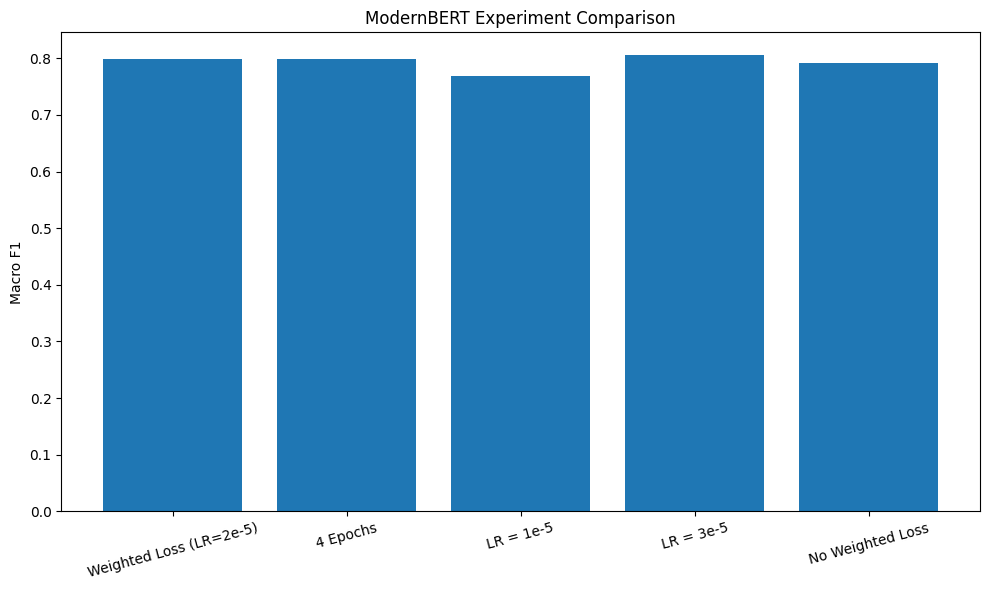

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    final_results_df["Experiment"],
    final_results_df["Macro_F1"]
)

plt.xticks(rotation=15)

plt.ylabel("Macro F1")

plt.title("ModernBERT Experiment Comparison")

plt.tight_layout()

plt.show()

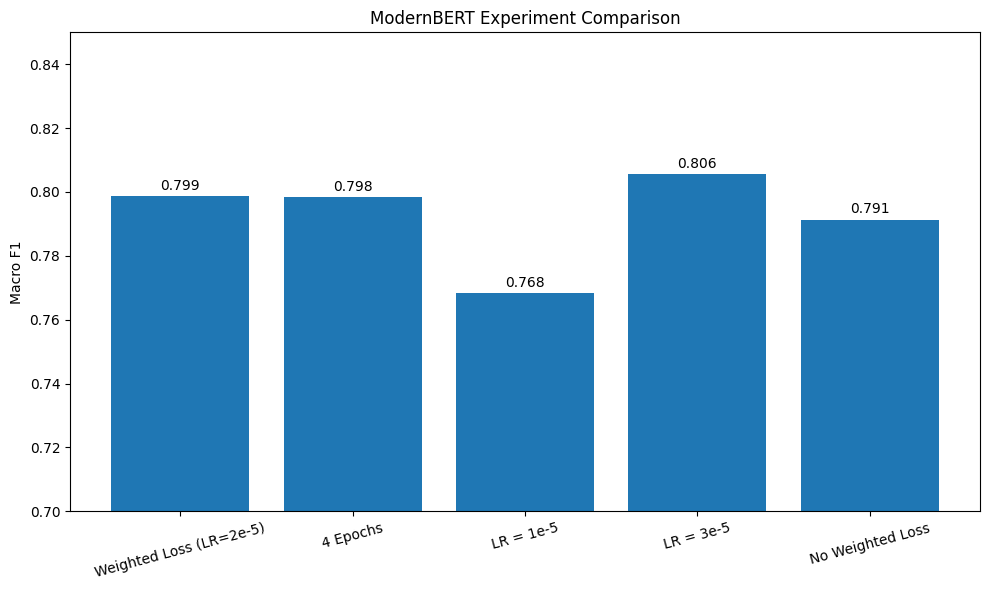

Macro F1 comparison plot saved


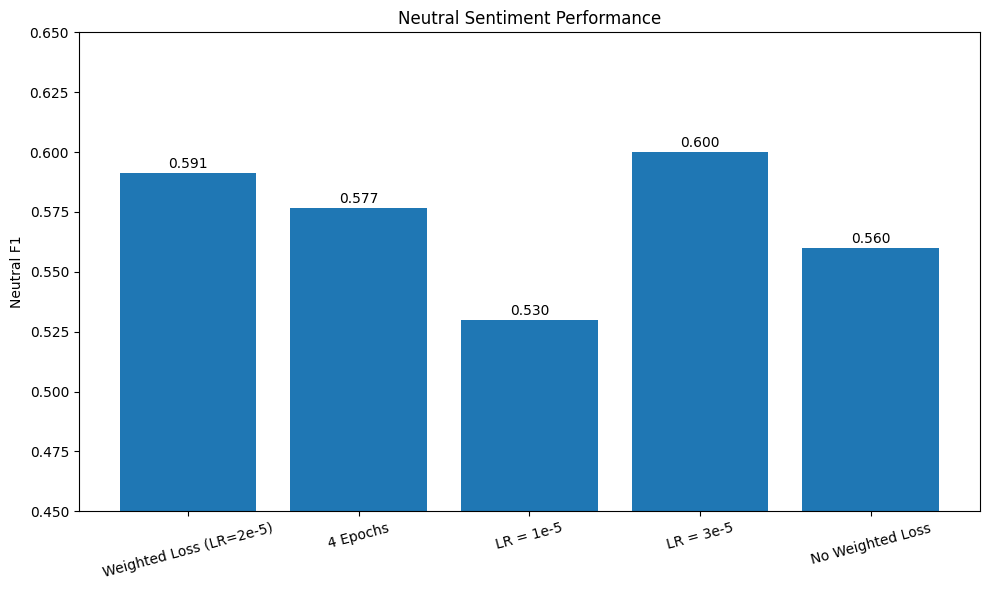

Neutral F1 comparison plot saved


In [93]:
import matplotlib.pyplot as plt

# =========================
# MACRO F1 COMPARISON PLOT
# =========================

plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results_df["Experiment"],
    final_results_df["Macro_F1"]
)

# Add value labels above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.ylabel("Macro F1")

plt.title("ModernBERT Experiment Comparison")

# ==================================
# ZOOMED Y-AXIS FOR BETTER VISIBILITY
# ==================================

plt.ylim(0.70, 0.85)

plt.tight_layout()

# Save high-quality figure
plt.savefig(
    "/content/drive/MyDrive/ABSA/results/modernbert_macrof1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Macro F1 comparison plot saved")

import matplotlib.pyplot as plt

# ==================================
# NEUTRAL SENTIMENT PERFORMANCE PLOT
# ==================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results_df["Experiment"],
    final_results_df["Neutral_F1"]
)

# Add value labels above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.ylabel("Neutral F1")

plt.title("Neutral Sentiment Performance")

# ==================================
# ZOOMED Y-AXIS FOR BETTER VISIBILITY
# ==================================

plt.ylim(0.45, 0.65)

plt.tight_layout()

# Save high-quality figure
plt.savefig(
    "/content/drive/MyDrive/ABSA/results/modernbert_neutralf1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Neutral F1 comparison plot saved")

In [87]:
final_predictions_df = test_df.copy()

final_predictions_df["true_label"] = y_true

final_predictions_df["predicted_label"] = y_pred

label_reverse_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

final_predictions_df["true_sentiment"] = (
    final_predictions_df["true_label"]
    .map(label_reverse_map)
)

final_predictions_df["predicted_sentiment"] = (
    final_predictions_df["predicted_label"]
    .map(label_reverse_map)
)

print(final_predictions_df.head())

                                              review                 aspect  \
0  The programming language( Scheme/ Dr. Racket) ...   programming language   
1  This class is literally just epsilon and delta...         mobius quizzes   
2  Overall content heavy and quite a tricky cours...                 course   
3  Professor Sneed's class was a semi tough one. ...  Professor Sneed class   
4  Despite many ppl complaining about the Mobius ...                 desmos   

  sentiment  domain       row_id  \
0  negative  course   course_188   
1  negative  course  course_3409   
2  negative  course   course_254   
3  positive  course  course_1797   
4  positive  course  course_3891   

                                          input_text  label  true_label  \
0  [DOMAIN] course [ASPECT] programming language ...      0           0   
1  [DOMAIN] course [ASPECT] mobius quizzes [TEXT]...      0           0   
2  [DOMAIN] course [ASPECT] course [TEXT] Overall...      0           0   
3  [DOMA

In [88]:
final_predictions_df.to_csv(
    "/content/drive/MyDrive/ABSA/predictions/modernbert_multidomain_predictions.csv",
    index=False
)

print("Official ModernBERT multidomain predictions saved")

Official ModernBERT multidomain predictions saved


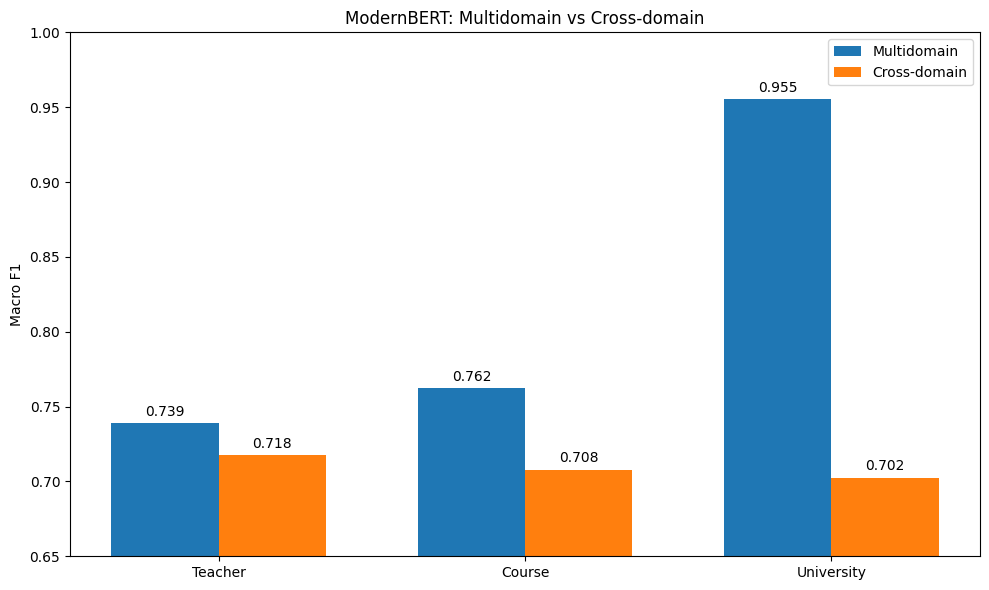

Comparison plot saved


In [96]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# DOMAIN NAMES
# =========================================

domains_display = [
    "Teacher",
    "Course",
    "University"
]

# =========================================
# REAL MULTIDOMAIN SCORES
# =========================================

multidomain_scores = [
    0.739026,
    0.762199,
    0.955299
]

# =========================================
# REAL CROSS-DOMAIN SCORES
# =========================================

crossdomain_scores = [
    0.717548,
    0.707828,
    0.702398
]

x = np.arange(len(domains_display))

width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(
    x - width/2,
    multidomain_scores,
    width,
    label="Multidomain"
)

bars2 = plt.bar(
    x + width/2,
    crossdomain_scores,
    width,
    label="Cross-domain"
)

# =========================================
# VALUE LABELS
# =========================================

for bar in bars1:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

for bar in bars2:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(x, domains_display)

plt.ylabel("Macro F1")

plt.title("ModernBERT: Multidomain vs Cross-domain")

plt.legend()

# =========================================
# ZOOMED Y-AXIS
# =========================================

plt.ylim(0.65, 1.00)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/ABSA/results/modernbert_multivs_cross_macrof1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Comparison plot saved")

In [100]:
import os

print(os.listdir("/content/drive/.shortcut-targets-by-id"))

[]


In [101]:
import pandas as pd

# =========================================
# LOAD MULTIDOMAIN PREDICTIONS
# =========================================

multi_df = pd.read_csv(
    "/content/drive/MyDrive/ABSA/predictions/modernbert_multidomain_predictions.csv"
)

# =========================================
# LOAD CROSS-DOMAIN PREDICTIONS
# =========================================

teacher_cross = pd.read_csv(
    "/content/drive/MyDrive/ABSA/predictions/course_university_to_teacher_best_predictions.csv"
)

course_cross = pd.read_csv(
    "/content/drive/MyDrive/ABSA/predictions/university_teacher_to_course_best_predictions.csv"
)

university_cross = pd.read_csv(
    "/content/drive/MyDrive/ABSA/predictions/course_teacher_to_university_best_predictions.csv"
)

# =========================================
# COMBINE CROSS-DOMAIN PREDICTIONS
# =========================================

cross_df = pd.concat([
    teacher_cross,
    course_cross,
    university_cross
]).reset_index(drop=True)

print("Multidomain rows:", len(multi_df))
print("Cross-domain rows:", len(cross_df))

# =========================================
# MERGE USING ROW_ID
# =========================================

comparison_df = multi_df.merge(
    cross_df[
        [
            "row_id",
            "predicted_sentiment"
        ]
    ],
    on="row_id",
    suffixes=(
        "_multidomain",
        "_crossdomain"
    )
)

print("Merged rows:", len(comparison_df))

comparison_df.head()

Multidomain rows: 2532
Cross-domain rows: 2532
Merged rows: 2532


,review,aspect,sentiment,domain,row_id,input_text,label,true_label,predicted_label,true_sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain
0,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,course,course_188,[DOMAIN] course [ASPECT] programming language ...,0,0,0,negative,negative,negative
1,This class is literally just epsilon and delta...,mobius quizzes,negative,course,course_3409,[DOMAIN] course [ASPECT] mobius quizzes [TEXT]...,0,0,0,negative,negative,negative
2,Overall content heavy and quite a tricky cours...,course,negative,course,course_254,[DOMAIN] course [ASPECT] course [TEXT] Overall...,0,0,0,negative,negative,negative
3,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,course,course_1797,[DOMAIN] course [ASPECT] Professor Sneed class...,2,2,0,positive,negative,negative
4,Despite many ppl complaining about the Mobius ...,desmos,positive,course,course_3891,[DOMAIN] course [ASPECT] desmos [TEXT] Despite...,2,2,2,positive,positive,positive


In [102]:
disagreement_df = comparison_df[
    comparison_df["predicted_sentiment_multidomain"]
    !=
    comparison_df["predicted_sentiment_crossdomain"]
]

print("Total disagreements:", len(disagreement_df))

disagreement_df[
    [
        "domain",
        "review",
        "aspect",
        "true_sentiment",
        "predicted_sentiment_multidomain",
        "predicted_sentiment_crossdomain"
    ]
].head(20)

Total disagreements: 306


,domain,review,aspect,true_sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain
7,course,Very interesting course! You cover a wide rang...,material,neutral,neutral,positive
12,course,Theory-based statistics course that is actuall...,taking this course,neutral,neutral,negative
18,course,Very straightforward course- the courseware pr...,amount of information,negative,neutral,negative
21,course,some memorization required for the midterm,midterm,neutral,neutral,negative
24,course,Standard PD course.,PD course,neutral,neutral,positive
29,course,"Very birdy course, you learn how to communicat...",course,positive,positive,neutral
45,course,"Definitely not an easy course, especially if y...",new content,neutral,neutral,negative
58,course,Continuation of high school/ first year dynami...,doing the work,positive,negative,positive
62,course,"For the audit portion, don't go to class; you ...",audit portion,neutral,neutral,positive
67,course,It's like BIO 130 but with a focus on genetic....,course,neutral,negative,neutral


In [103]:
multi_correct_cross_wrong = disagreement_df[
    (
        disagreement_df["predicted_sentiment_multidomain"]
        ==
        disagreement_df["true_sentiment"]
    )
    &
    (
        disagreement_df["predicted_sentiment_crossdomain"]
        !=
        disagreement_df["true_sentiment"]
    )
]

print(
    "Multidomain Correct, Cross-domain Wrong:",
    len(multi_correct_cross_wrong)
)

multi_correct_cross_wrong[
    [
        "domain",
        "review",
        "aspect",
        "true_sentiment",
        "predicted_sentiment_multidomain",
        "predicted_sentiment_crossdomain"
    ]
].head(20)

Multidomain Correct, Cross-domain Wrong: 181


,domain,review,aspect,true_sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain
7,course,Very interesting course! You cover a wide rang...,material,neutral,neutral,positive
12,course,Theory-based statistics course that is actuall...,taking this course,neutral,neutral,negative
21,course,some memorization required for the midterm,midterm,neutral,neutral,negative
24,course,Standard PD course.,PD course,neutral,neutral,positive
29,course,"Very birdy course, you learn how to communicat...",course,positive,positive,neutral
45,course,"Definitely not an easy course, especially if y...",new content,neutral,neutral,negative
62,course,"For the audit portion, don't go to class; you ...",audit portion,neutral,neutral,positive
85,course,PROS:( 1) Time period given for each project i...,projects,negative,negative,positive
102,course,This course is very useful and would definitel...,slides,neutral,neutral,negative
118,course,"Hard course, but fair examinations and labs",examinations,positive,positive,negative


In [104]:
cross_correct_multi_wrong = disagreement_df[
    (
        disagreement_df["predicted_sentiment_crossdomain"]
        ==
        disagreement_df["true_sentiment"]
    )
    &
    (
        disagreement_df["predicted_sentiment_multidomain"]
        !=
        disagreement_df["true_sentiment"]
    )
]

print(
    "Cross-domain Correct, Multidomain Wrong:",
    len(cross_correct_multi_wrong)
)

cross_correct_multi_wrong[
    [
        "domain",
        "review",
        "aspect",
        "true_sentiment",
        "predicted_sentiment_multidomain",
        "predicted_sentiment_crossdomain"
    ]
].head(20)

Cross-domain Correct, Multidomain Wrong: 89


,domain,review,aspect,true_sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain
18,course,Very straightforward course- the courseware pr...,amount of information,negative,neutral,negative
58,course,Continuation of high school/ first year dynami...,doing the work,positive,negative,positive
67,course,It's like BIO 130 but with a focus on genetic....,course,neutral,negative,neutral
76,course,This course is more interesting than 102 and m...,course,positive,neutral,positive
90,course,"If you don't need physics, or won't put in a l...",this content,negative,neutral,negative
127,course,"I took this course as a science elective, and ...",course,neutral,positive,neutral
129,course,The course was quite simple. The quizzes were ...,quizzes,positive,neutral,positive
185,course,"BIOL 130 was not an easy course, but the infor...",textbook,neutral,negative,neutral
216,course,Nice course that teaches you how to write simp...,algorithms or data structures,negative,neutral,negative
229,course,Some parts are interesting but some a lot of i...,Some parts,positive,neutral,positive


In [105]:
disagreement_df.to_csv(
    "/content/drive/MyDrive/ABSA/results/multidomain_vs_crossdomain_disagreements.csv",
    index=False
)

multi_correct_cross_wrong.to_csv(
    "/content/drive/MyDrive/ABSA/results/multidomain_correct_cross_wrong.csv",
    index=False
)

cross_correct_multi_wrong.to_csv(
    "/content/drive/MyDrive/ABSA/results/crossdomain_correct_multidomain_wrong.csv",
    index=False
)

print("Disagreement analysis files saved successfully")

Disagreement analysis files saved successfully


In [106]:
import pandas as pd

# =========================================
# SUMMARY COMPARISON TABLE
# =========================================

comparison_summary_df = pd.DataFrame({

    "Metric": [
        "Total Test Samples",
        "Total Disagreements",
        "Multidomain Correct / Cross-domain Wrong",
        "Cross-domain Correct / Multidomain Wrong"
    ],

    "Value": [
        len(comparison_df),
        len(disagreement_df),
        len(multi_correct_cross_wrong),
        len(cross_correct_multi_wrong)
    ]
})

print(comparison_summary_df)

# =========================================
# SAVE SUMMARY TABLE
# =========================================

comparison_summary_df.to_csv(
    "/content/drive/MyDrive/ABSA/results/disagreement_summary.csv",
    index=False
)

print("Disagreement summary saved")

                                     Metric  Value
0                        Total Test Samples   2532
1                       Total Disagreements    306
2  Multidomain Correct / Cross-domain Wrong    181
3  Cross-domain Correct / Multidomain Wrong     89
Disagreement summary saved


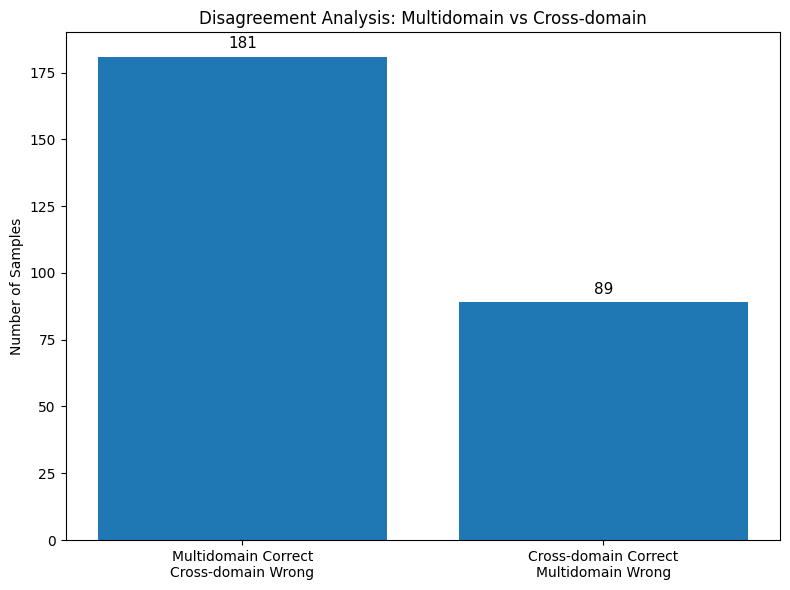

Disagreement analysis plot saved


In [107]:
import matplotlib.pyplot as plt

# =========================================
# DISAGREEMENT ANALYSIS PLOT
# =========================================

labels = [
    "Multidomain Correct\nCross-domain Wrong",
    "Cross-domain Correct\nMultidomain Wrong"
]

values = [
    len(multi_correct_cross_wrong),
    len(cross_correct_multi_wrong)
]

plt.figure(figsize=(8,6))

bars = plt.bar(
    labels,
    values
)

# =========================================
# VALUE LABELS
# =========================================

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,
        f"{height}",
        ha='center',
        fontsize=11
    )

plt.ylabel("Number of Samples")

plt.title(
    "Disagreement Analysis: Multidomain vs Cross-domain"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/ABSA/results/disagreement_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Disagreement analysis plot saved")

In [108]:
final_summary_df = pd.DataFrame({

    "Category": [
        "Best Overall Macro F1",
        "Best Overall Accuracy",
        "Best Neutral F1",
        "Multidomain Correct / Cross-domain Wrong",
        "Cross-domain Correct / Multidomain Wrong",
        "Teacher Multidomain Macro F1",
        "Course Multidomain Macro F1",
        "University Multidomain Macro F1"
    ],

    "Value": [
        0.805572,
        0.883491,
        0.600000,
        181,
        89,
        0.739026,
        0.762199,
        0.955299
    ]
})

print(final_summary_df)

final_summary_df.to_csv(
    "/content/drive/MyDrive/ABSA/results/final_dissertation_summary.csv",
    index=False
)

print("Final dissertation summary saved")

                                   Category       Value
0                     Best Overall Macro F1    0.805572
1                     Best Overall Accuracy    0.883491
2                           Best Neutral F1    0.600000
3  Multidomain Correct / Cross-domain Wrong  181.000000
4  Cross-domain Correct / Multidomain Wrong   89.000000
5              Teacher Multidomain Macro F1    0.739026
6               Course Multidomain Macro F1    0.762199
7           University Multidomain Macro F1    0.955299
Final dissertation summary saved


In [109]:
interpretation_notes = """

MODERNBERT MULTIDOMAIN VS CROSS-DOMAIN ANALYSIS

1. Multidomain training consistently outperformed cross-domain training across all evaluated domains.

2. The multidomain model achieved higher Macro F1 scores:
   - Teacher: 0.739 vs 0.718
   - Course: 0.762 vs 0.708
   - University: 0.955 vs 0.702

3. The largest performance improvement was observed on the University domain, suggesting that multidomain learning improved contextual representation quality and shared sentiment understanding.

4. Disagreement analysis further demonstrated multidomain superiority:
   - Multidomain Correct / Cross-domain Wrong: 181 samples
   - Cross-domain Correct / Multidomain Wrong: 89 samples

5. These findings indicate that shared representation learning across educational domains improved overall sentiment generalization.

6. Neutral sentiment remained the most difficult class across all experiments due to:
   - mixed sentiment expressions
   - conditional opinions
   - implicit sentiment cues
   - contextual ambiguity

7. Weighted loss improved minority-class handling and increased Neutral F1 performance.

8. Error analysis revealed frequent confusion between:
   - neutral and negative sentiment
   - neutral and positive sentiment
   - mixed-polarity reviews

9. Row-level prediction tracking using row_id enabled scientifically aligned sample-level comparison between multidomain and cross-domain predictions.

"""

print(interpretation_notes)



MODERNBERT MULTIDOMAIN VS CROSS-DOMAIN ANALYSIS

1. Multidomain training consistently outperformed cross-domain training across all evaluated domains.

2. The multidomain model achieved higher Macro F1 scores:
   - Teacher: 0.739 vs 0.718
   - Course: 0.762 vs 0.708
   - University: 0.955 vs 0.702

3. The largest performance improvement was observed on the University domain, suggesting that multidomain learning improved contextual representation quality and shared sentiment understanding.

4. Disagreement analysis further demonstrated multidomain superiority:
   - Multidomain Correct / Cross-domain Wrong: 181 samples
   - Cross-domain Correct / Multidomain Wrong: 89 samples

5. These findings indicate that shared representation learning across educational domains improved overall sentiment generalization.

6. Neutral sentiment remained the most difficult class across all experiments due to:
   - mixed sentiment expressions
   - conditional opinions
   - implicit sentiment cues
   - c